# External Validation on OAI — HKA Agreement

Validates the **U-Net baseline** landmark model (`best_model_unet_global.pt`) on **OAI full-limb radiographs** by comparing the **HKA computed from the model's predicted landmarks** against **OAI's clinical (OAISYS) HKA**.

**Ground truth.** Run `prepare_oai_hka.py` on the two NDA exports (`oai_xralign01.txt`, `oai_xrmeta01.txt`) to build `oai_hka_groundtruth.csv` — one row per full-limb image (barcode) with `hka_side1` / `hka_side2`. In the released data that's **3,831 full-limb images / ~7,600 knees**, HKA signed with 0 = neutral (mean ≈ −1.2°), and an **OAI inter-reader SD ≈ 0.30°** that serves as the benchmark your model should approach.

**Scope.** HKA uses femoral-head / knee-centre / ankle-centre, so this externally validates the **mechanical-axis (alignment) landmarks** on a large out-of-distribution cohort — not the osteotomy hinge or plateau-width points (HKA is blind to them; those stay on your annotated set). Frame it as "the alignment backbone generalises."

**Workflow:** (1) build the CSV with `prepare_oai_hka.py`; (2) download the Full-Limb DICOMs for those barcodes; (3) set the config cell; (4) run top-to-bottom; (5) **read the laterality/sign diagnostic at the end and fix `IMAGE_LEFT_IS_SIDE` / `HKA_SIGN_FLIP` before trusting the numbers.**

> Expect a small Bland-Altman bias from the knee-centre definition (your plateau-midpoint vs OAISYS notch/spines); the ICC and limits-of-agreement spread are what tell you the geometry transfers.

## Imports & Configuration

In [1]:
import os
import random
import math
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Reusable pipeline from the local `hto` package (must sit next to this notebook).
from hto.model import UNetKeypointHalfHeatmap   # same architecture the baseline trained
from hto.data import preprocess_global_image    # letterbox to a square canvas
from hto.metrics import extract_coordinates      # per-channel argmax decode

SEED          = 42
TARGET_SIZE   = 768
HEATMAP_SCALE = 0.5

# ── U-Net baseline configuration (must match the trained checkpoint) ──────────
UNET_BASE_CH    = 64
UNET_BILINEAR   = False
CHECKPOINT_PATH = "kfolds_models/best_model_fold1.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware device registered: {device}")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

Hardware device registered: cuda


## OAI Configuration — edit these

In [2]:
# ============================================================================
# OAI external-validation config  —  paths wired for this machine
# ============================================================================
OAI_IMAGE_DIR   = "/tf/data/hka/oai_dicoms"                # extracted <barcode>.dcm files
OAI_HKA_CSV     = "/tf/data/hka/oai_hka_groundtruth.csv"   # HKA ground truth
CHECKPOINT_PATH = "/tf/notebooks/kfolds_models/best_model_unet_global.pt"  # trained U-Net baseline

HKA_KEY_COL   = "barcode"        # == DICOM filename stem
HKA_SIDE1_COL = "hka_side1"
HKA_SIDE2_COL = "hka_side2"

# OAISYS convention: signed, 0 = neutral, negative = varus
HKA_NEUTRAL_180    = False
# image-hemisphere <-> OAI side + sign. Defaults below; the diagnostic at the
# bottom confirms them. If its most-positive row differs, change these two and re-run.
IMAGE_LEFT_IS_SIDE = "1"
HKA_SIGN_FLIP      = False

DICOM_INVERT    = False          # MONOCHROME1 auto-handled; set True only if images look inverted
EXCLUDE_ABS_DEV = 25.0           # |predicted HKA| beyond this (deg) => likely model failure; flag & exclude
NEUTRAL_BAND    = 3.0


## Image Loading & Preprocessing

In [3]:
# ---- OAI image loader (DICOM or standard image) + model normalisation ----
def load_oai_image(path):
    """Load an OAI radiograph as an RGB PIL image (handles DICOM windowing / inversion)."""
    ext = os.path.splitext(path)[1].lower()
    if ext in (".dcm", ".dicom", ""):
        import pydicom
        ds  = pydicom.dcmread(path)
        arr = ds.pixel_array.astype(np.float32)
        slope = ds.get("RescaleSlope", 1.0);     slope = 1.0 if slope in (None, "") else float(slope)
        inter = ds.get("RescaleIntercept", 0.0); inter = 0.0 if inter in (None, "") else float(inter)
        arr = arr * slope + inter
        lo, hi = np.percentile(arr, (1, 99))                              # robust window
        arr = np.clip((arr - lo) / max(hi - lo, 1e-6), 0.0, 1.0)
        if ds.get("PhotometricInterpretation", "") == "MONOCHROME1" or DICOM_INVERT:
            arr = 1.0 - arr
        return Image.fromarray((arr * 255).astype(np.uint8)).convert("RGB")
    return Image.open(path).convert("RGB")

_IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_IMNET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
def to_model_tensor(pil):
    t = torch.from_numpy(np.array(pil)).permute(2, 0, 1).float() / 255.0
    return (t - _IMNET_MEAN) / _IMNET_STD


## HKA from Predicted Landmarks

In [4]:
# ---- HKA from predicted landmarks (mechanical axis: hip - knee_centre - ankle_centre) ----
# Slots within each hemisphere: 0 femur_head | 1 knee_inner | 2 ost_point | 3 knee_outer
#                               4 ankle_inner | 5 ankle_outer   (ost_point unused for HKA)
def hka_from_side(pts6, neutral180=None, sign_flip=None):
    if neutral180 is None: neutral180 = HKA_NEUTRAL_180
    if sign_flip is None:  sign_flip  = HKA_SIGN_FLIP
    fh = pts6[0]; ki = pts6[1]; ko = pts6[3]
    kc = 0.5 * (ki + ko); ac = 0.5 * (pts6[4] + pts6[5])
    vf = fh - kc; vt = ac - kc                                  # knee->hip, knee->ankle
    cross = vf[0]*vt[1] - vf[1]*vt[0]; dot = vf[0]*vt[0] + vf[1]*vt[1]
    ang = abs(math.degrees(math.atan2(cross, dot)))            # ~180 for a straight leg
    dev = 180.0 - ang
    # laterality-consistent sign: knee_outer(lateral) - knee_inner(medial) is THIS leg's
    # medial->lateral direction, so the same clinical deformity gets the same sign on the
    # left and right legs (their raw cross-product signs are mirror-opposite otherwise).
    lat  = 1.0 if (ko[0] - ki[0]) >= 0 else -1.0
    sign = (-1.0 if cross < 0 else 1.0) * lat * (-1.0 if sign_flip else 1.0)
    return (180.0 - sign*dev) if neutral180 else (sign*dev)

def predict_landmarks(pil):
    """OAI image -> [12,2] landmark coords in 768 letterbox space (angle-preserving)."""
    canon, _, _ = preprocess_global_image(pil, TARGET_SIZE)
    with torch.no_grad():
        hms = model_global(to_model_tensor(canon).unsqueeze(0).to(device))   # linear head — no sigmoid
    return extract_coordinates(hms.cpu(), scale_factor=1.0 / HEATMAP_SCALE)[0].numpy()

# self-test: a straight synthetic leg must give HKA = 180
_straight = np.array([[100,0],[90,500],[0,0],[110,500],[90,1000],[110,1000]], float)
assert abs(hka_from_side(_straight, neutral180=True, sign_flip=False) - 180.0) < 0.1, "HKA self-test failed"
_vL = np.array([[400,100],[415,500],[0,0],[385,500],[450,900],[430,900]], float)  # image-left,  varus
_vR = np.array([[400,100],[385,500],[0,0],[415,500],[350,900],[370,900]], float)  # image-right, mirror varus
assert abs(hka_from_side(_vL) - hka_from_side(_vR)) < 1e-6, "left/right sign inconsistent"
print("HKA self-test passed (straight -> 180; mirror legs share sign via knee_inner/outer reference).")

HKA self-test passed (straight -> 180; mirror legs share sign via knee_inner/outer reference).


## Model & Checkpoint

In [5]:
# ---- build the U-Net baseline (inference only) ----
model_global = UNetKeypointHalfHeatmap(
    num_keypoints=12, base_ch=UNET_BASE_CH, bilinear=UNET_BILINEAR
).to(device)
model_global.eval()
print(f"U-Net baseline initialised on {device}  (base_ch={UNET_BASE_CH}, bilinear={UNET_BILINEAR}).")

U-Net baseline initialised on cuda  (base_ch=64, bilinear=False).


In [6]:
# ---- load the trained model checkpoint ----
if os.path.exists(CHECKPOINT_PATH):
    model_global.load_state_dict(torch.load(CHECKPOINT_PATH, weights_only=True, map_location=device))
    model_global.eval()
    print(f"Loaded checkpoint '{CHECKPOINT_PATH}'.")
else:
    print(f"Checkpoint '{CHECKPOINT_PATH}' not found — set CHECKPOINT_PATH.")

Loaded checkpoint '/tf/notebooks/kfolds_models/best_model_unet_global.pt'.


## Load OAI HKA Ground Truth

In [7]:
# ---- load the OAI HKA ground-truth table (one row per full-limb image) ----
if os.path.exists(OAI_HKA_CSV):
    import pandas as pd
    hka_df = pd.read_csv(OAI_HKA_CSV, dtype={HKA_KEY_COL: str})
    hka_lookup = hka_df.set_index(HKA_KEY_COL)
    nboth = int(hka_df[[HKA_SIDE1_COL, HKA_SIDE2_COL]].notna().all(axis=1).sum())
    print(f"Loaded {len(hka_df)} full-limb images ({nboth} with both knees). Columns: {list(hka_df.columns)}")
    if {'readsd_side1', 'readsd_side2'}.issubset(hka_df.columns):
        oai_reader_sd = pd.concat([hka_df['readsd_side1'], hka_df['readsd_side2']]).dropna().mean()
        print(f"OAI within-knee reader agreement (SD): {oai_reader_sd:.3f} deg  <- benchmark to match")
else:
    print(f"Ground-truth CSV not found at '{OAI_HKA_CSV}' — run prepare_oai_hka.py first.")

Loaded 3831 full-limb images (3816 with both knees). Columns: ['barcode', 'subj', 'visit', 'sex', 'ageyears', 'hka_side1', 'hka_side2', 'nread_side1', 'nread_side2', 'readsd_side1', 'readsd_side2']
OAI within-knee reader agreement (SD): 0.298 deg  <- benchmark to match


## Run Inference & Match to OAI HKA

In [8]:
# ---- run the model on OAI full-limb images, compute HKA, match by barcode ----
import glob
import pandas as pd
IMG_EXTS = (".dcm", ".dicom", ".png", ".jpg", ".jpeg", ".tif", ".tiff")
NEUTRAL  = 180.0 if HKA_NEUTRAL_180 else 0.0

if os.path.isdir(OAI_IMAGE_DIR) and os.path.exists(CHECKPOINT_PATH) and 'hka_lookup' in locals():
    paths = sorted(p for p in glob.glob(os.path.join(OAI_IMAGE_DIR, "*"))
                   if os.path.splitext(p)[1].lower() in IMG_EXTS)
    print(f"Found {len(paths)} images; matching to ground truth by barcode (filename stem)...")
    model_global.eval()
    oai_results, diag_records = [], []
    n_total = n_failed = n_flagged = 0

    try:
        from tqdm.auto import tqdm
        pbar = tqdm(paths, desc="OAI inference", unit="img"); use_tqdm = True
    except Exception:
        pbar = paths; use_tqdm = False

    for i, path in enumerate(pbar):
        stem = os.path.splitext(os.path.basename(path))[0]
        if stem not in hka_lookup.index:
            continue
        n_total += 1
        row = hka_lookup.loc[stem]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]
        try:
            coords = predict_landmarks(load_oai_image(path))             # [12,2], 768 space
        except Exception:
            n_failed += 1; continue

        p_left  = hka_from_side(coords[0:6])                             # image-left leg  (slots 0-5)
        p_right = hka_from_side(coords[6:12])                            # image-right leg (slots 6-11)
        pred_side = ({"1": p_left, "2": p_right} if IMAGE_LEFT_IS_SIDE == "1"
                     else {"1": p_right, "2": p_left})
        g1 = pd.to_numeric(row.get(HKA_SIDE1_COL), errors="coerce")
        g2 = pd.to_numeric(row.get(HKA_SIDE2_COL), errors="coerce")
        diag_records.append(dict(barcode=stem, img_left=p_left, img_right=p_right,
                                 oai_side1=g1, oai_side2=g2))

        for side, gt in [("1", g1), ("2", g2)]:
            if pd.isna(gt):
                continue
            pred = pred_side[side]
            flagged = abs(pred - NEUTRAL) > EXCLUDE_ABS_DEV
            n_flagged += int(flagged)
            oai_results.append(dict(barcode=stem, side=side, pred_hka=float(pred),
                                    oai_hka=float(gt), abs_err=abs(float(pred) - float(gt)),
                                    flagged=bool(flagged)))

        if use_tqdm:
            pbar.set_postfix(matched=n_total, knees=len(oai_results), failed=n_failed)
        elif i % 200 == 0:
            print(f"  {i}/{len(paths)} images | matched {n_total}, knees {len(oai_results)}, "
                  f"failed {n_failed}", flush=True)

    print(f"Matched {len(oai_results)} knees across {n_total} images "
          f"({n_failed} inference failures; {n_flagged} flagged |HKA-neutral|>{EXCLUDE_ABS_DEV:.0f} deg).")
else:
    print("Set OAI_IMAGE_DIR / OAI_HKA_CSV / CHECKPOINT_PATH and run the cells above first.")


Found 3831 images; matching to ground truth by barcode (filename stem)...


OAI inference:   0%|          | 0/3831 [00:00<?, ?img/s]

Matched 7647 knees across 3831 images (0 inference failures; 814 flagged |HKA-neutral|>25 deg).


## Agreement Analysis

OAI EXTERNAL VALIDATION — HKA AGREEMENT
knees analysed: 6833  (excluded 814 flagged of 7647)
MAE  = 1.78°    RMSE = 4.40°
bias = +0.16°    95% LoA = [-8.46, 8.77]°
ICC(2,1) = 0.486    Pearson r = 0.526    Spearman = 0.810
magnitude-only r(|pred|,|OAI|) = +0.469  (high while signed r is low => a sign problem, not localisation)
reference: OAI's own inter-reader SD = 0.30°  (your error approaching this = matching the human readers)

By alignment (stratified on OAI HKA):
  varus  (<-3)     n= 1898  MAE=2.14°
  neutral (+/-3)   n= 4323  MAE=1.57°
  valgus (>3)      n=  612  MAE=2.11°


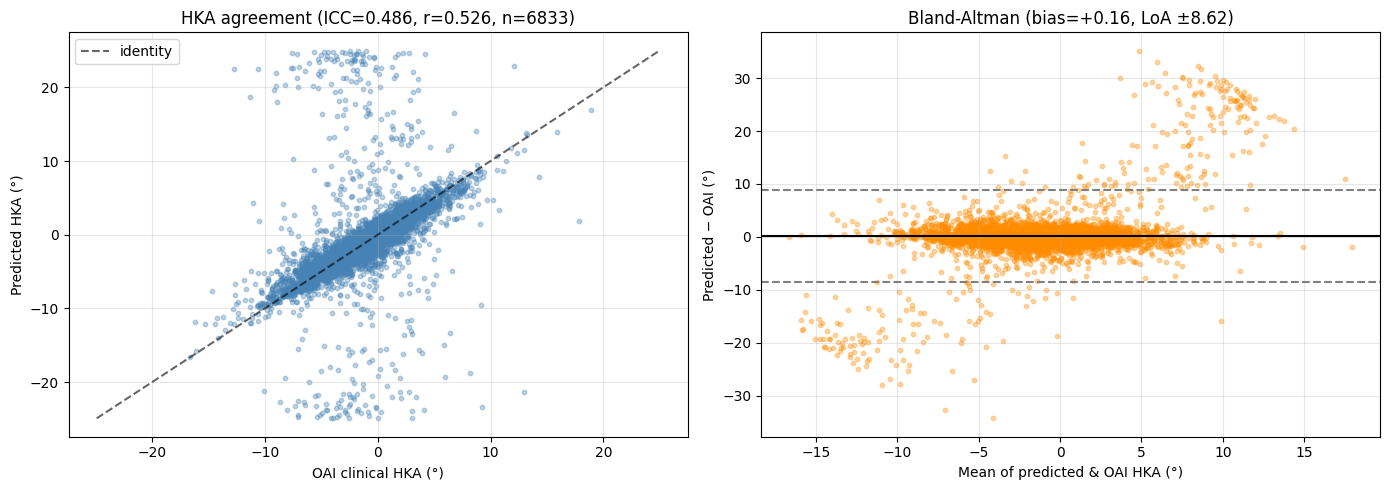


Laterality / sign diagnostic (Pearson r — pick the clearly-positive option, set config to match):
  image-left=side1, no flip   : r=+0.105
  image-left=side2, no flip   : r=+0.054
  image-left=side1, sign flip : r=-0.105
  image-left=side2, sign flip : r=-0.054
  If the most-positive isn't your current IMAGE_LEFT_IS_SIDE / HKA_SIGN_FLIP, update them and re-run.

Saved: hto_oai_external_validation.csv


In [9]:
# ---- agreement: MAE / ICC / Bland-Altman vs OAI HKA (+ reader-agreement benchmark) ----
if 'oai_results' in locals() and oai_results:
    import pandas as pd
    from scipy.stats import pearsonr, spearmanr

    def icc21(M):
        X = np.asarray(M, float); n, k = X.shape; g = X.mean()
        SSR = k * ((X.mean(1) - g) ** 2).sum(); SSC = n * ((X.mean(0) - g) ** 2).sum()
        SSE = ((X - g) ** 2).sum() - SSR - SSC
        MSR = SSR / (n - 1); MSC = SSC / (k - 1); MSE = SSE / ((n - 1) * (k - 1))
        return (MSR - MSE) / (MSR + (k - 1) * MSE + (k / n) * (MSC - MSE))

    R  = pd.DataFrame(oai_results)
    Rv = R[~R["flagged"]].reset_index(drop=True)
    pred = Rv["pred_hka"].values; oai = Rv["oai_hka"].values; n = len(Rv)
    diff = pred - oai
    bias = diff.mean(); sd = diff.std(ddof=1); loa = (bias - 1.96 * sd, bias + 1.96 * sd)
    mae = np.abs(diff).mean(); rmse = float(np.sqrt((diff ** 2).mean()))
    icc = icc21(np.c_[pred, oai]); r, _ = pearsonr(pred, oai); rho, _ = spearmanr(pred, oai)

    print("=" * 64); print("OAI EXTERNAL VALIDATION \u2014 HKA AGREEMENT"); print("=" * 64)
    print(f"knees analysed: {n}  (excluded {int(R['flagged'].sum())} flagged of {len(R)})")
    print(f"MAE  = {mae:.2f}\u00b0    RMSE = {rmse:.2f}\u00b0")
    print(f"bias = {bias:+.2f}\u00b0    95% LoA = [{loa[0]:.2f}, {loa[1]:.2f}]\u00b0")
    print(f"ICC(2,1) = {icc:.3f}    Pearson r = {r:.3f}    Spearman = {rho:.3f}")
    from scipy.stats import pearsonr as _pr
    print(f"magnitude-only r(|pred|,|OAI|) = {_pr(np.abs(pred), np.abs(oai))[0]:+.3f}  "
          f"(high while signed r is low => a sign problem, not localisation)")
    if 'oai_reader_sd' in locals():
        print(f"reference: OAI's own inter-reader SD = {oai_reader_sd:.2f}\u00b0  "
              f"(your error approaching this = matching the human readers)")

    print("\nBy alignment (stratified on OAI HKA):")
    nb = NEUTRAL_BAND; ref = 180.0 if HKA_NEUTRAL_180 else 0.0
    for label, m in [(f"varus  (<{ref-nb:.0f})", oai < ref - nb),
                     (f"neutral (+/-{nb:.0f})",  np.abs(oai - ref) <= nb),
                     (f"valgus (>{ref+nb:.0f})", oai > ref + nb)]:
        if m.sum() > 0:
            print(f"  {label:16s} n={int(m.sum()):5d}  MAE={np.abs(diff[m]).mean():.2f}\u00b0")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    lo = float(min(pred.min(), oai.min())); hi = float(max(pred.max(), oai.max()))
    ax1.scatter(oai, pred, alpha=0.35, s=10, color="steelblue")
    ax1.plot([lo, hi], [lo, hi], "k--", alpha=0.6, label="identity")
    ax1.set_xlabel("OAI clinical HKA (\u00b0)"); ax1.set_ylabel("Predicted HKA (\u00b0)")
    ax1.set_title(f"HKA agreement (ICC={icc:.3f}, r={r:.3f}, n={n})"); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.scatter((pred + oai) / 2, diff, alpha=0.35, s=10, color="darkorange")
    ax2.axhline(bias, color="k"); ax2.axhline(loa[0], color="gray", ls="--"); ax2.axhline(loa[1], color="gray", ls="--")
    ax2.set_xlabel("Mean of predicted & OAI HKA (\u00b0)"); ax2.set_ylabel("Predicted \u2212 OAI (\u00b0)")
    ax2.set_title(f"Bland-Altman (bias={bias:+.2f}, LoA \u00b1{1.96*sd:.2f})"); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # ---- laterality / sign diagnostic: confirm IMAGE_LEFT_IS_SIDE and HKA_SIGN_FLIP ----
    if 'diag_records' in locals() and diag_records:
        D = pd.DataFrame(diag_records)
        def corr_under(left_is_side1, flip):
            rows = []
            for _, d in D.iterrows():
                pl, pr = d["img_left"], d["img_right"]
                if flip:
                    pl = (360.0 - pl) if HKA_NEUTRAL_180 else -pl
                    pr = (360.0 - pr) if HKA_NEUTRAL_180 else -pr
                ps = ({"1": pl, "2": pr} if left_is_side1 else {"1": pr, "2": pl})
                for s, col in [("1", "oai_side1"), ("2", "oai_side2")]:
                    g = d.get(col, np.nan)
                    if not pd.isna(g):
                        rows.append((ps[s], g))
            if len(rows) < 3:
                return float("nan")
            a = np.array(rows); return pearsonr(a[:, 0], a[:, 1])[0]
        print("\nLaterality / sign diagnostic (Pearson r \u2014 pick the clearly-positive option, set config to match):")
        print(f"  image-left=side1, no flip   : r={corr_under(True , False):+.3f}")
        print(f"  image-left=side2, no flip   : r={corr_under(False, False):+.3f}")
        print(f"  image-left=side1, sign flip : r={corr_under(True , True ):+.3f}")
        print(f"  image-left=side2, sign flip : r={corr_under(False, True ):+.3f}")
        print("  If the most-positive isn't your current IMAGE_LEFT_IS_SIDE / HKA_SIGN_FLIP, update them and re-run.")

    try:
        R.to_csv("hto_oai_external_validation.csv", index=False); print("\nSaved: hto_oai_external_validation.csv")
    except OSError as e:
        print(f"(CSV not written here: {e}. Table available as `R`.)")
else:
    print("Run the inference cell above first.")

## Diagnostic — what is the model actually seeing?
Overlays predicted landmarks (red = image-left slots 0-5, cyan = image-right slots 6-11) on the preprocessed 768 input. If the image looks wrong (inverted, washed-out, squashed, single-leg) or the points aren't on hip/knee/ankle, that's the r=0 cause.

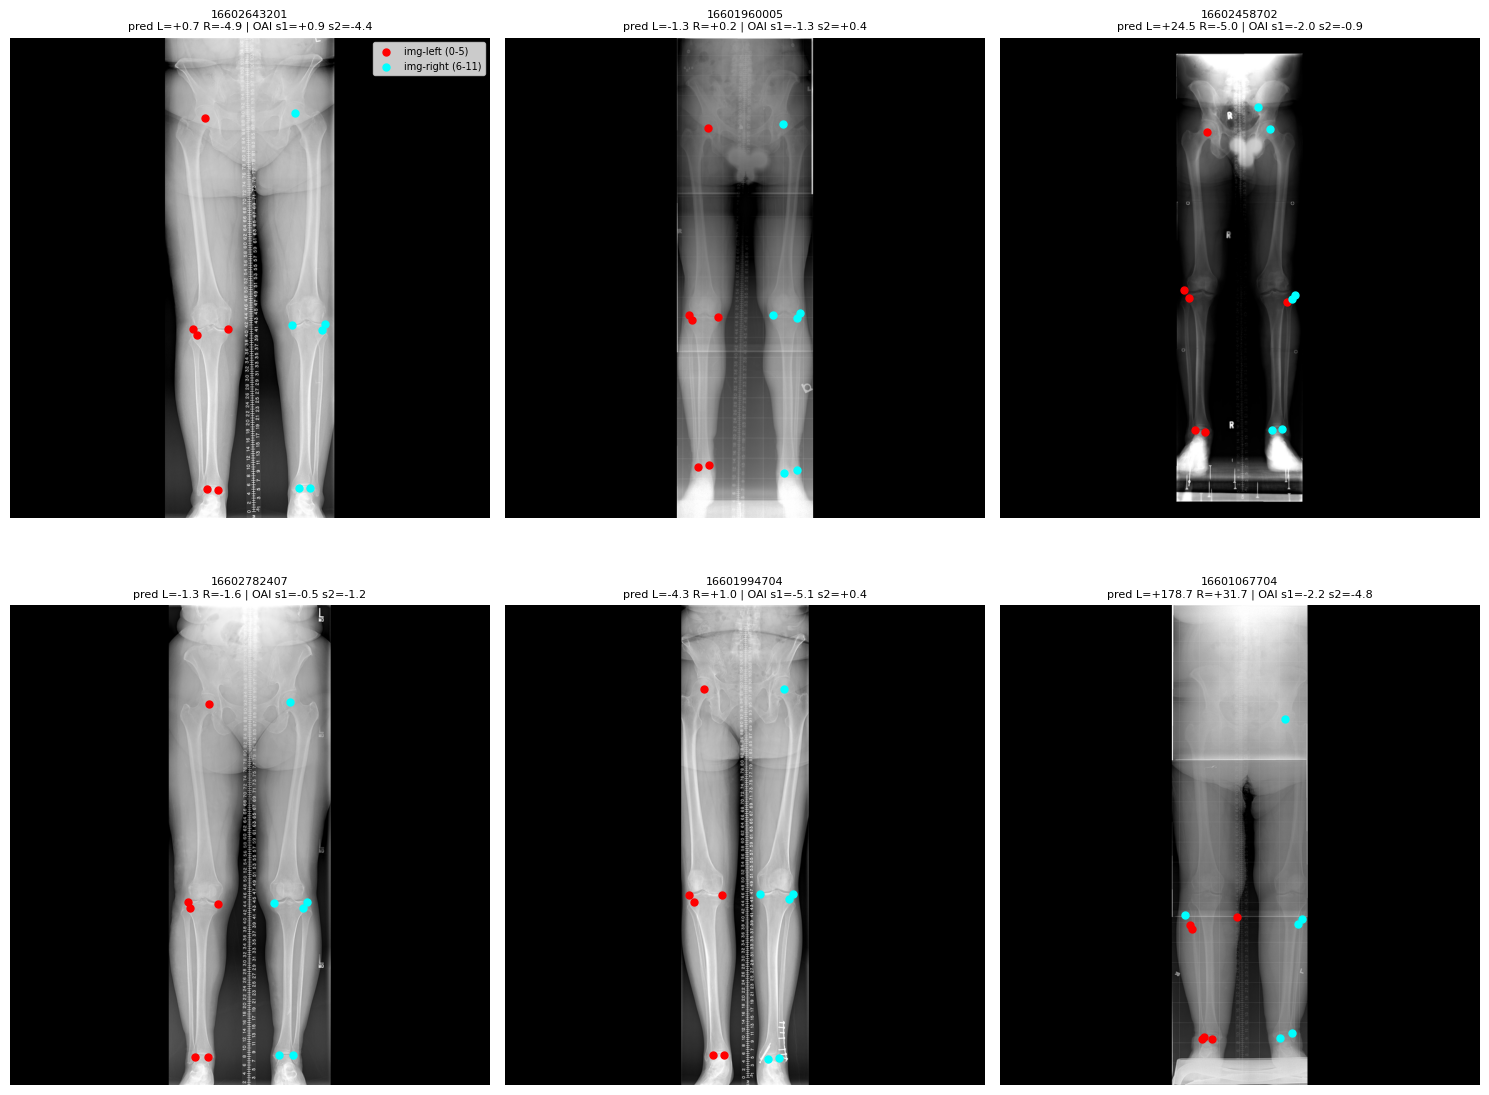

predicted HKA: mean=0.02 sd=27.50  |  OAI HKA: mean=-1.24 sd=3.42
If predicted SD << OAI SD (~3.5), the model is outputting near-constant HKA (not localizing).


In [10]:
# ---- DIAGNOSTIC: predicted landmarks on a few OAI images ----
import random as _rnd
_rnd.seed(0)
_bcs = _rnd.sample(list(hka_lookup.index), 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 12))
for ax, bc in zip(axes.ravel(), _bcs):
    path = os.path.join(OAI_IMAGE_DIR, f"{bc}.dcm")
    try:
        pil = load_oai_image(path)
        canon, _, _ = preprocess_global_image(pil, TARGET_SIZE)
        with torch.no_grad():
            hms = model_global(to_model_tensor(canon).unsqueeze(0).to(device))
        coords = extract_coordinates(hms.cpu(), scale_factor=1.0 / HEATMAP_SCALE)[0].numpy()
        ax.imshow(np.array(canon), cmap="gray")
        ax.scatter(coords[0:6, 0],  coords[0:6, 1],  c="red",  s=25, label="img-left (0-5)")
        ax.scatter(coords[6:12, 0], coords[6:12, 1], c="cyan", s=25, label="img-right (6-11)")
        hl, hr = hka_from_side(coords[0:6]), hka_from_side(coords[6:12])
        row = hka_lookup.loc[bc]
        if isinstance(row, pd.DataFrame): row = row.iloc[0]
        s1 = pd.to_numeric(row.get(HKA_SIDE1_COL), errors="coerce")
        s2 = pd.to_numeric(row.get(HKA_SIDE2_COL), errors="coerce")
        ax.set_title(f"{bc}\npred L={hl:+.1f} R={hr:+.1f} | OAI s1={s1:+.1f} s2={s2:+.1f}", fontsize=8)
    except Exception as e:
        ax.set_title(f"{bc}: {type(e).__name__}: {e}", fontsize=7)
    ax.axis("off")
axes.ravel()[0].legend(fontsize=7, loc="upper right")
plt.tight_layout(); plt.show()

import pandas as pd
R = pd.DataFrame(oai_results)
print("predicted HKA: mean=%.2f sd=%.2f  |  OAI HKA: mean=%.2f sd=%.2f"
      % (R['pred_hka'].mean(), R['pred_hka'].std(), R['oai_hka'].mean(), R['oai_hka'].std()))
print("If predicted SD << OAI SD (~3.5), the model is outputting near-constant HKA (not localizing).")
